In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder,OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv('student_dropout_dataset_v3.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [5]:
df['Family_Income'] = df['Family_Income'].fillna(df['Family_Income'].mean())

In [6]:
df['Stress_Index'] = df['Stress_Index'].fillna(df['Stress_Index'].mean())

In [7]:
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean())

In [8]:
df['Parental_Education'] = df['Parental_Education'].fillna('None')


In [9]:
df['Parental_Education'].value_counts()

Parental_Education
Bachelor       3949
High School    3072
Master         2003
None            511
PhD             465
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['None', 'High School', 'Bachelor', 'Master', 'PhD']])

df[['Parental_Education']] = encoder.fit_transform(df[['Parental_Education']])

In [11]:
df = pd.get_dummies(df, columns=['Department', 'Semester'])

In [12]:
df

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,...,Dropout,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science,Semester_Year 1,Semester_Year 2,Semester_Year 3,Semester_Year 4
0,1,22.1,Male,25000.000000,Yes,3.360000,86.1,2,20.4,Yes,...,0,True,False,False,False,False,True,False,False,False
1,2,20.7,Male,25000.000000,Yes,4.300000,68.0,2,44.0,No,...,1,False,False,False,True,False,False,False,True,False
2,3,22.4,Male,40183.000000,Yes,4.400000,70.9,0,48.9,Yes,...,0,True,False,False,False,False,True,False,False,False
3,4,24.4,Male,38377.247474,Yes,4.014592,82.2,2,38.6,No,...,1,False,False,True,False,False,True,False,False,False
4,5,20.5,Female,25319.000000,Yes,4.190000,75.7,1,23.0,No,...,0,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,23.9,Female,42286.000000,No,4.620000,92.0,0,10.0,Yes,...,0,True,False,False,False,False,False,True,False,False
9996,9997,17.0,Female,61103.000000,Yes,2.870000,75.2,3,32.4,No,...,1,False,True,False,False,False,True,False,False,False
9997,9998,19.4,Male,25000.000000,Yes,4.730000,74.9,4,25.4,No,...,0,False,True,False,False,False,False,False,False,True
9998,9999,22.1,Female,40302.000000,Yes,5.850000,74.2,1,5.0,No,...,0,False,False,True,False,False,True,False,False,False


In [13]:
df.drop('Student_ID',axis=1,inplace=True)

In [14]:
df = df.replace({
    True: 1, False: 0,
    'Male': 1, 'Female': 0,
    'Yes': 1, 'No': 0
})

In [15]:
df

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,...,Dropout,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science,Semester_Year 1,Semester_Year 2,Semester_Year 3,Semester_Year 4
0,22.1,1,25000.000000,1,3.360000,86.1,2,20.4,1,0,...,0,1,0,0,0,0,1,0,0,0
1,20.7,1,25000.000000,1,4.300000,68.0,2,44.0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,22.4,1,40183.000000,1,4.400000,70.9,0,48.9,1,0,...,0,1,0,0,0,0,1,0,0,0
3,24.4,1,38377.247474,1,4.014592,82.2,2,38.6,0,0,...,1,0,0,1,0,0,1,0,0,0
4,20.5,0,25319.000000,1,4.190000,75.7,1,23.0,0,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,23.9,0,42286.000000,0,4.620000,92.0,0,10.0,1,1,...,0,1,0,0,0,0,0,1,0,0
9996,17.0,0,61103.000000,1,2.870000,75.2,3,32.4,0,1,...,1,0,1,0,0,0,1,0,0,0
9997,19.4,1,25000.000000,1,4.730000,74.9,4,25.4,0,0,...,0,0,1,0,0,0,0,0,0,1
9998,22.1,0,40302.000000,1,5.850000,74.2,1,5.0,0,1,...,0,0,0,1,0,0,1,0,0,0


In [46]:
df.corr()['Dropout']

Age                       0.007585
Gender                   -0.007265
Family_Income            -0.010849
Internet_Access          -0.043205
Study_Hours_per_Day      -0.087177
Attendance_Rate          -0.163539
Assignment_Delay_Days     0.082327
Travel_Time_Minutes       0.028080
Part_Time_Job             0.036781
Scholarship              -0.006661
Stress_Index              0.249356
GPA                      -0.460352
Semester_GPA             -0.445396
CGPA                     -0.444807
Parental_Education       -0.018974
Dropout                   1.000000
Department_Arts           0.004738
Department_Business      -0.002516
Department_CS            -0.001587
Department_Engineering    0.005386
Department_Science       -0.005920
Semester_Year 1          -0.018570
Semester_Year 2           0.011627
Semester_Year 3           0.004645
Semester_Year 4           0.002181
Name: Dropout, dtype: float64

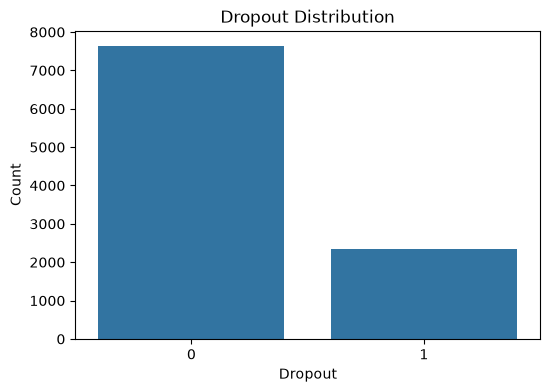

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Dropout', data=df)

plt.title('Dropout Distribution')
plt.xlabel('Dropout')
plt.ylabel('Count')

plt.show()


In [17]:
X=df.drop(['Dropout'],axis=1)
y=df['Dropout']


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

Dropout
0    7646
1    7646
Name: count, dtype: int64


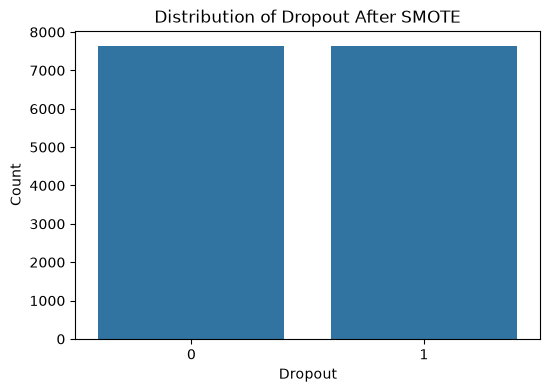

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)

plt.title("Distribution of Dropout After SMOTE")
plt.xlabel("Dropout")
plt.ylabel("Count")

plt.show()

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,random_state=42,test_size=0.2)

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Train and tune
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

# Best model
best_dt = grid_search.best_estimator_

# Predictions
y_pred = best_dt.predict(X_test)

# Evaluation
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}

Best Cross Validation Score:
0.8159896761465723

Test Accuracy: 0.8195488721804511

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1565
           1       0.85      0.77      0.81      1494

    accuracy                           0.82      3059
   macro avg       0.82      0.82      0.82      3059
weighted avg       0.82      0.82      0.82      3059



In [40]:
from sklearn.linear_model import LogisticRegression


In [41]:
lr=LogisticRegression()

In [42]:
lr.fit(X_train,y_train)

c:\Users\nic\Desktop\student_\student\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [43]:
y_pred2=lr.predict(X_test)

In [44]:
accuracy_score(y_test,y_pred2)

0.7459954233409611

In [45]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred2)

array([[1173,  392],
       [ 385, 1109]])